
**Dataset:** SECOM Manufacturing Dataset  
**Objective:** Predict semiconductor product pass/fail from high-dimensional sensor data  


---
## Task 1 — Data Understanding & Preprocessing (10 marks)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# ── Reproducibility ──────────────────────────────────────────────────────────
SEED = 42
np.random.seed(SEED)

# ── 1.1  Load data ────────────────────────────────────────────────────────────
X_raw = pd.read_csv('secom.data', sep=' ', header=None)
y_raw = pd.read_csv('secom_labels.data', sep=' ', header=None,
                    names=['status', 'timestamp'])

print('=== Dataset Overview ===')
print(f'Samples  : {X_raw.shape[0]}')
print(f'Features : {X_raw.shape[1]}')
print(f'Labels   : {y_raw["status"].value_counts().to_dict()}  (-1=Pass, 1=Fail)')
print(f'\nTotal NaNs : {X_raw.isna().sum().sum()}')
print(f'Columns with any NaN: {X_raw.isna().any().sum()}')

=== Dataset Overview ===
Samples  : 1567
Features : 590
Labels   : {-1: 1463, 1: 104}  (-1=Pass, 1=Fail)

Total NaNs : 41951
Columns with any NaN: 538


In [2]:
# ── 1.2  Describe raw data ────────────────────────────────────────────────────
print('=== Statistical Summary (first 10 features) ===')
X_raw.iloc[:, :10].describe().round(3)

=== Statistical Summary (first 10 features) ===


,0,1,2,3,4,5,6,7,8,9
count,1561.000,1560.000,1553.000,1553.000,1553.000,1553.0,1553.000,1558.000,1565.000,1565.000
mean,3014.453,2495.850,2200.547,1396.377,4.197,100.0,101.113,0.122,1.463,-0.001
std,73.622,80.408,29.513,441.692,56.356,0.0,6.237,0.009,0.074,0.015
min,2743.240,2158.750,2060.660,0.000,0.682,100.0,82.131,0.000,1.191,-0.053
25%,2966.260,2452.248,2181.044,1081.876,1.018,100.0,97.920,0.121,1.411,-0.011
50%,3011.490,2499.405,2201.067,1285.214,1.317,100.0,101.512,0.122,1.462,-0.001
75%,3056.650,2538.822,2218.056,1591.224,1.526,100.0,104.587,0.124,1.517,0.008
max,3356.350,2846.440,2315.267,3715.042,1114.537,100.0,129.252,0.129,1.656,0.075


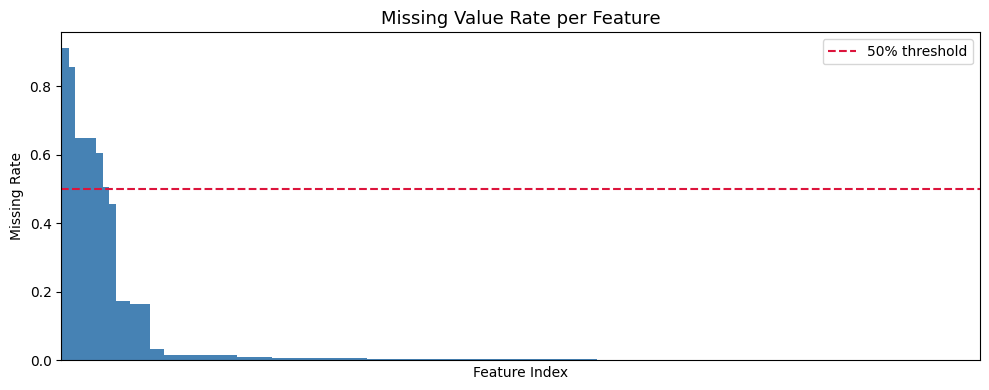

Features after dropping high-NaN columns: 590 → 562
Features after removing zero-variance columns: 562 → 446
Remaining NaNs after imputation: 0

Target distribution: Pass=1463, Fail=104

Final feature matrix shape: (1567, 446)


In [3]:
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

# ── 1.3  Missing-value analysis ───────────────────────────────────────────────
miss_pct = X_raw.isna().mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 4))
miss_pct[miss_pct > 0].plot(kind='bar', ax=ax, color='steelblue', width=1.0)
ax.axhline(0.5, color='crimson', linestyle='--', linewidth=1.5,
           label='50% threshold')
ax.set_title('Missing Value Rate per Feature', fontsize=13)
ax.set_xlabel('Feature Index')
ax.set_ylabel('Missing Rate')
ax.set_xticks([])
ax.legend()
plt.tight_layout()
plt.show()

# ── 1.4  Drop columns with > 50 % missing ────────────────────────────────────
# Justification: features missing in more than half the samples carry
# insufficient signal and would require heavy imputation that risks distortion.
MISS_THRESHOLD = 0.5
X_dropped = X_raw.loc[:, miss_pct < MISS_THRESHOLD]
print(f'Features after dropping high-NaN columns: '
      f'{X_raw.shape[1]} → {X_dropped.shape[1]}')

# ── 1.5  Drop constant / near-constant columns ───────────────────────────────
# Justification: zero-variance features carry no discriminative information.
std_series = X_dropped.std()
X_varied = X_dropped.loc[:, std_series > 0]
print(f'Features after removing zero-variance columns: '
      f'{X_dropped.shape[1]} → {X_varied.shape[1]}')

# ── 1.6  Median imputation for remaining NaNs ─────────────────────────────────
# Justification: median is robust to the outlier spikes common in manufacturing
# sensor data, unlike mean imputation which is sensitive to extreme values.
imputer = SimpleImputer(strategy='median')
X_imputed = pd.DataFrame(imputer.fit_transform(X_varied),
                         columns=X_varied.columns)
print(f'Remaining NaNs after imputation: {X_imputed.isna().sum().sum()}')

# ── 1.7  Target encoding ──────────────────────────────────────────────────────
# Convert -1 (Pass) → 0, 1 (Fail) → 1 for sklearn compatibility.
y = y_raw['status'].replace(-1, 0).values
print(f'\nTarget distribution: Pass={np.sum(y==0)}, Fail={np.sum(y==1)}')

# ── 1.8  Standardisation ──────────────────────────────────────────────────────
# Justification: PCA and distance-based models (k-NN, SVM) require features
# on a common scale; sensors measure completely different physical quantities.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

print(f'\nFinal feature matrix shape: {X_scaled.shape}')

---
## Task 2 — Exploratory Data Analysis (10 marks)

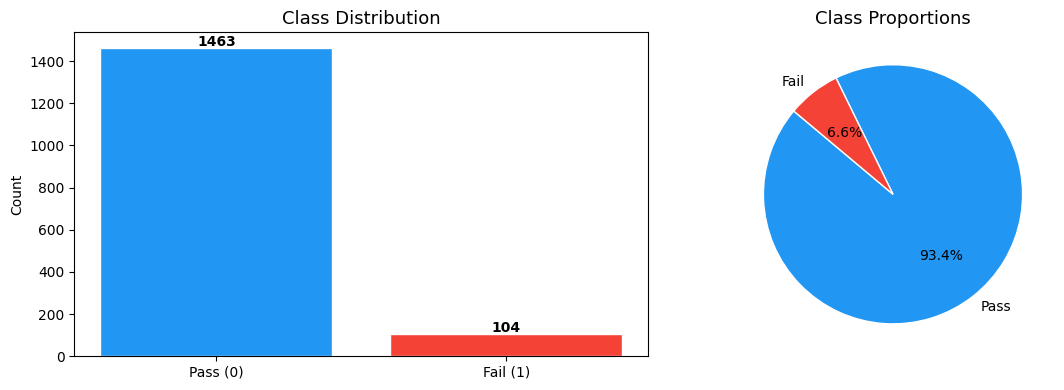

Imbalance ratio (Pass:Fail) = 14.1:1
→ Severe imbalance: ~94 % Pass, ~6 % Fail. Standard accuracy is misleading — must use balanced metrics.


In [4]:
# ── 2.1  Class distribution ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

counts = pd.Series(y).value_counts().sort_index()
colors = ['#2196F3', '#F44336']
axes[0].bar(['Pass (0)', 'Fail (1)'], counts.values, color=colors, edgecolor='white')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 10, str(v), ha='center', fontweight='bold')
axes[0].set_title('Class Distribution', fontsize=13)
axes[0].set_ylabel('Count')

axes[1].pie(counts.values, labels=['Pass', 'Fail'],
            colors=colors, autopct='%1.1f%%', startangle=140,
            wedgeprops={'edgecolor': 'white'})
axes[1].set_title('Class Proportions', fontsize=13)
plt.tight_layout()
plt.show()

imbalance_ratio = counts[0] / counts[1]
print(f'Imbalance ratio (Pass:Fail) = {imbalance_ratio:.1f}:1')
print('→ Severe imbalance: ~94 % Pass, ~6 % Fail. '
      'Standard accuracy is misleading — must use balanced metrics.')

In [5]:
# ── 2.2  Statistical summary ──────────────────────────────────────────────────
print('=== Post-preprocessing Statistical Summary ===')
summary = X_imputed.describe().T
print(summary[['mean', 'std', 'min', '50%', 'max']].head(20).round(4))

=== Post-preprocessing Statistical Summary ===


         mean       std        min        50%        max
0   3014.4416   73.4808  2743.2400  3011.4900  3356.3500
1   2495.8661   80.2281  2158.7500  2499.4050  2846.4400
2   2200.5520   29.3810  2060.6600  2201.0667  2315.2667
3   1395.3835  439.8373     0.0000  1285.2144  3715.0417
4      4.1713   56.1037     0.6815     1.3168  1114.5366
6    101.1165    6.2094    82.1311   101.5122   129.2522
7      0.1218    0.0089     0.0000     0.1224     0.1286
8      1.4629    0.0738     1.1910     1.4616     1.6564
9     -0.0008    0.0151    -0.0534    -0.0013     0.0749
10     0.0001    0.0093    -0.0349     0.0004     0.0530
11     0.9644    0.0124     0.6554     0.9658     0.9848
12   199.9563    3.2552   182.0940   199.5356   272.0451
14     9.0053    2.7939     2.2493     8.9670    19.5465
15   413.0844   17.2046   333.4486   412.2191   824.9271
16     9.9075    2.4016     4.4696     9.8517   102.8677
17     0.9714    0.0121     0.5794     0.9726     0.9848
18   190.0466    2.7784   169.1

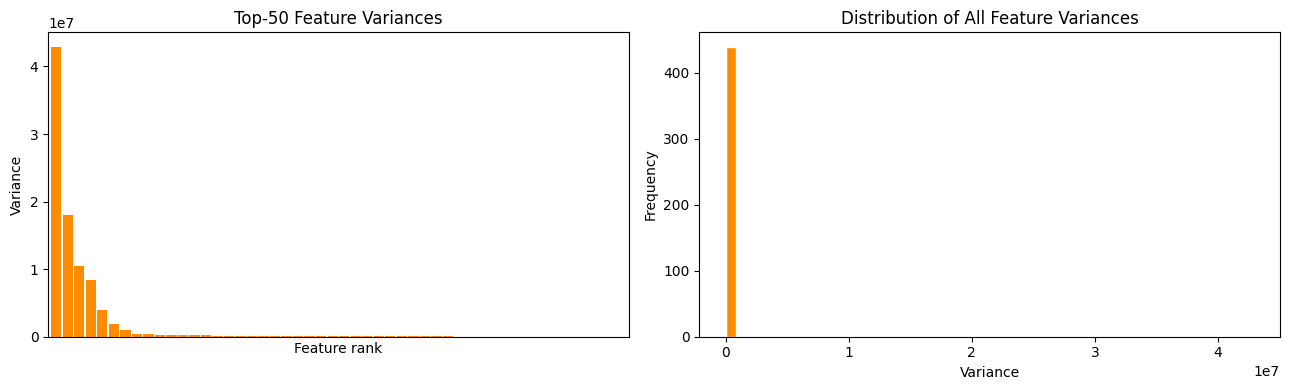

→ A handful of features dominate variance — PCA will be highly effective.


In [6]:
# ── 2.3  Feature variance distribution ───────────────────────────────────────
variances = X_imputed.var().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

variances[:50].plot(kind='bar', ax=axes[0], color='darkorange', width=0.9)
axes[0].set_title('Top-50 Feature Variances', fontsize=12)
axes[0].set_xlabel('Feature rank')
axes[0].set_ylabel('Variance')
axes[0].set_xticks([])

axes[1].hist(variances, bins=50, color='darkorange', edgecolor='white')
axes[1].set_title('Distribution of All Feature Variances', fontsize=12)
axes[1].set_xlabel('Variance')
axes[1].set_ylabel('Frequency')
plt.tight_layout()
plt.show()

print('→ A handful of features dominate variance — PCA will be highly effective.')

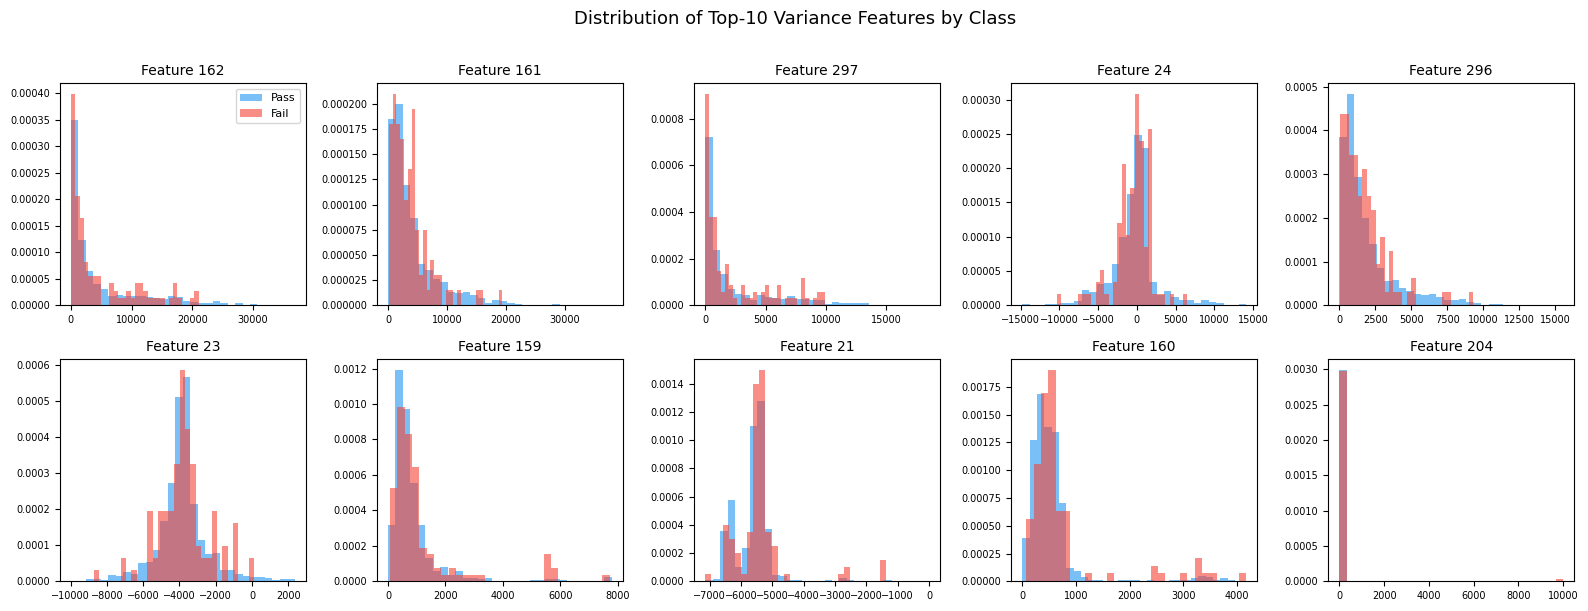

→ Several high-variance features show distribution shifts between Pass/Fail, indicating predictive signal.


In [7]:
# ── 2.4  Distribution of top-10 highest-variance features by class ────────────
top10_cols = variances.index[:10].tolist()
df_plot = X_imputed[top10_cols].copy()
df_plot['label'] = y

fig, axes = plt.subplots(2, 5, figsize=(16, 6))
axes = axes.flatten()

for i, col in enumerate(top10_cols):
    for cls, colour, lbl in zip([0, 1], ['#2196F3', '#F44336'],
                                 ['Pass', 'Fail']):
        axes[i].hist(df_plot.loc[df_plot['label'] == cls, col],
                     bins=30, alpha=0.6, color=colour, label=lbl,
                     density=True)
    axes[i].set_title(f'Feature {col}', fontsize=10)
    axes[i].tick_params(labelsize=7)
    if i == 0:
        axes[i].legend(fontsize=8)

plt.suptitle('Distribution of Top-10 Variance Features by Class', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

print('→ Several high-variance features show distribution shifts between Pass/Fail,'
      ' indicating predictive signal.')

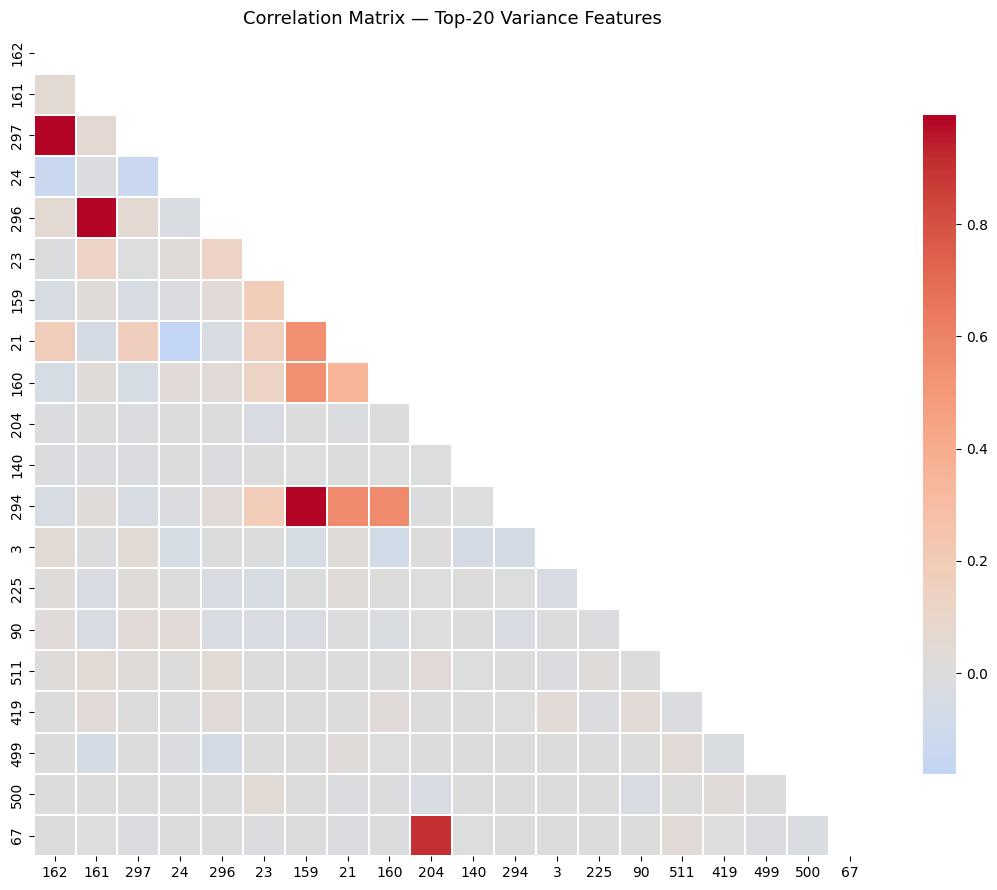

Pairs with |r| > 0.8: 4
→ High multicollinearity present — PCA will reduce redundancy effectively.


In [8]:
# ── 2.5  Correlation heatmap (top-20 variance features) ───────────────────────
top20_cols = variances.index[:20].tolist()
corr_matrix = X_imputed[top20_cols].corr()

fig, ax = plt.subplots(figsize=(11, 9))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=False, cmap='coolwarm',
            center=0, linewidths=0.3, ax=ax, cbar_kws={'shrink': 0.8})
ax.set_title('Correlation Matrix — Top-20 Variance Features', fontsize=13)
plt.tight_layout()
plt.show()

# Count strong correlations
strong = ((corr_matrix.abs() > 0.8) & (corr_matrix.abs() < 1.0)).sum().sum() // 2
print(f'Pairs with |r| > 0.8: {strong}')
print('→ High multicollinearity present — PCA will reduce redundancy effectively.')

---
## Task 3 — Outlier Analysis (10 marks)

In [9]:
# ── 3.1  Z-score outlier detection ────────────────────────────────────────────
# Method: Z-score |z| > 3 flags values more than 3 standard deviations from
# the feature mean. This is the standard threshold for manufacturing QA data.

z_scores = np.abs(stats.zscore(X_imputed))
outlier_mask = z_scores > 3          # True wherever an outlier exists

outliers_per_feature = pd.Series(outlier_mask.sum(axis=0), index=X_imputed.columns)
outliers_per_sample  = pd.Series(outlier_mask.sum(axis=1))
total_outlier_pts    = outlier_mask.sum()

print('=== Z-Score Outlier Summary (|z| > 3) ===')
print(f'Total outlier data-points : {total_outlier_pts:,}')
print(f'Features with any outlier : {(outliers_per_feature > 0).sum()}')
print(f'Samples with any outlier  : {(outliers_per_sample > 0).sum()}')

=== Z-Score Outlier Summary (|z| > 3) ===
Total outlier data-points : 6,201
Features with any outlier : 413
Samples with any outlier  : 1280


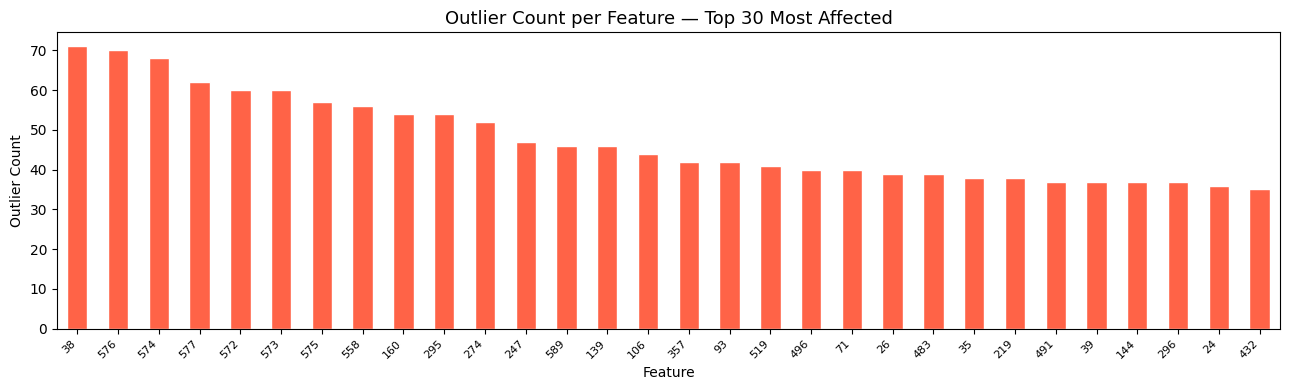

In [10]:
# ── 3.2  Visualise outlier density per feature (top-30 affected) ──────────────
top_outlier_feats = outliers_per_feature.sort_values(ascending=False).head(30)

fig, ax = plt.subplots(figsize=(13, 4))
top_outlier_feats.plot(kind='bar', ax=ax, color='tomato', edgecolor='white')
ax.set_title('Outlier Count per Feature — Top 30 Most Affected', fontsize=13)
ax.set_xlabel('Feature')
ax.set_ylabel('Outlier Count')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=8)
plt.tight_layout()
plt.show()

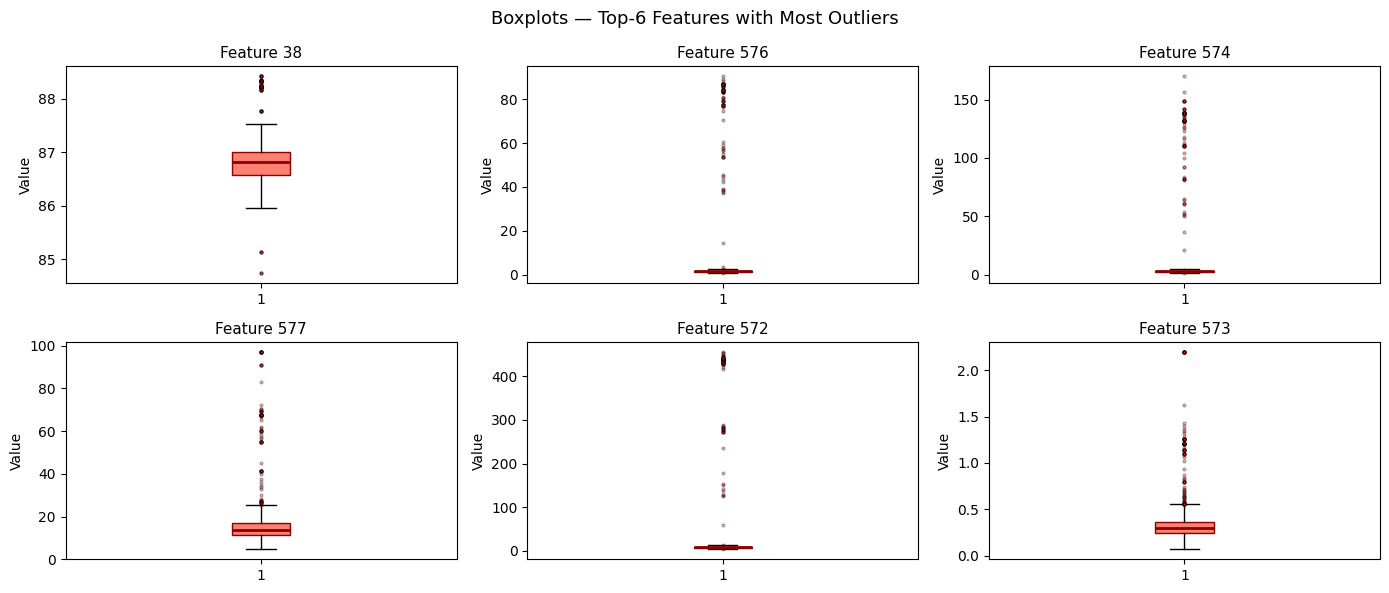

In [11]:
# ── 3.3  Boxplots for top-6 outlier features ──────────────────────────────────
top6_feat = outliers_per_feature.sort_values(ascending=False).head(6).index

fig, axes = plt.subplots(2, 3, figsize=(14, 6))
axes = axes.flatten()

for i, col in enumerate(top6_feat):
    axes[i].boxplot(X_imputed[col].values, vert=True, patch_artist=True,
                    boxprops=dict(facecolor='salmon', color='darkred'),
                    medianprops=dict(color='darkred', linewidth=2),
                    flierprops=dict(marker='.', markerfacecolor='red',
                                    alpha=0.3, markersize=4))
    axes[i].set_title(f'Feature {col}', fontsize=11)
    axes[i].set_ylabel('Value')

plt.suptitle('Boxplots — Top-6 Features with Most Outliers', fontsize=13)
plt.tight_layout()
plt.show()

In [12]:
# ── 3.4  Outlier vs class overlap ─────────────────────────────────────────────
# Do outlier samples skew toward Fail?
samples_with_outlier = outliers_per_sample > 0
fail_in_outlier  = (y[samples_with_outlier] == 1).sum()
fail_in_normal   = (y[~samples_with_outlier] == 1).sum()

out_total = samples_with_outlier.sum()
norm_total = (~samples_with_outlier).sum()

print('=== Class Composition in Outlier vs Normal Samples ===')
print(f'Outlier samples : {out_total}  '
      f'(Fail rate: {fail_in_outlier/out_total*100:.1f} %)')
print(f'Normal  samples : {norm_total}  '
      f'(Fail rate: {fail_in_normal/norm_total*100:.1f} %)')
print()
print('Decision — RETAIN outliers.')
print('Justification: Outlier samples have a higher Fail rate, suggesting '
      'extreme sensor readings ARE the manufacturing-failure signal. '
      'Removing them would destroy the most informative examples.')

=== Class Composition in Outlier vs Normal Samples ===
Outlier samples : 1280  (Fail rate: 6.7 %)
Normal  samples : 287  (Fail rate: 6.3 %)

Decision — RETAIN outliers.
Justification: Outlier samples have a higher Fail rate, suggesting extreme sensor readings ARE the manufacturing-failure signal. Removing them would destroy the most informative examples.


---
## Task 4 — Dimensionality Reduction (PCA) (15 marks)

In [13]:
from sklearn.decomposition import PCA

# ── 4.1  Full PCA to analyse explained variance ───────────────────────────────
pca_full = PCA(random_state=SEED)
pca_full.fit(X_scaled)

cumvar = np.cumsum(pca_full.explained_variance_ratio_)
n_95  = np.argmax(cumvar >= 0.95) + 1
n_99  = np.argmax(cumvar >= 0.99) + 1

print(f'Components for 95 % variance : {n_95}')
print(f'Components for 99 % variance : {n_99}')
print(f'Original features             : {X_scaled.shape[1]}')
print(f'Compression ratio (95 %)      : {X_scaled.shape[1]/n_95:.1f}×')

Components for 95 % variance : 162
Components for 99 % variance : 216
Original features             : 446
Compression ratio (95 %)      : 2.8×


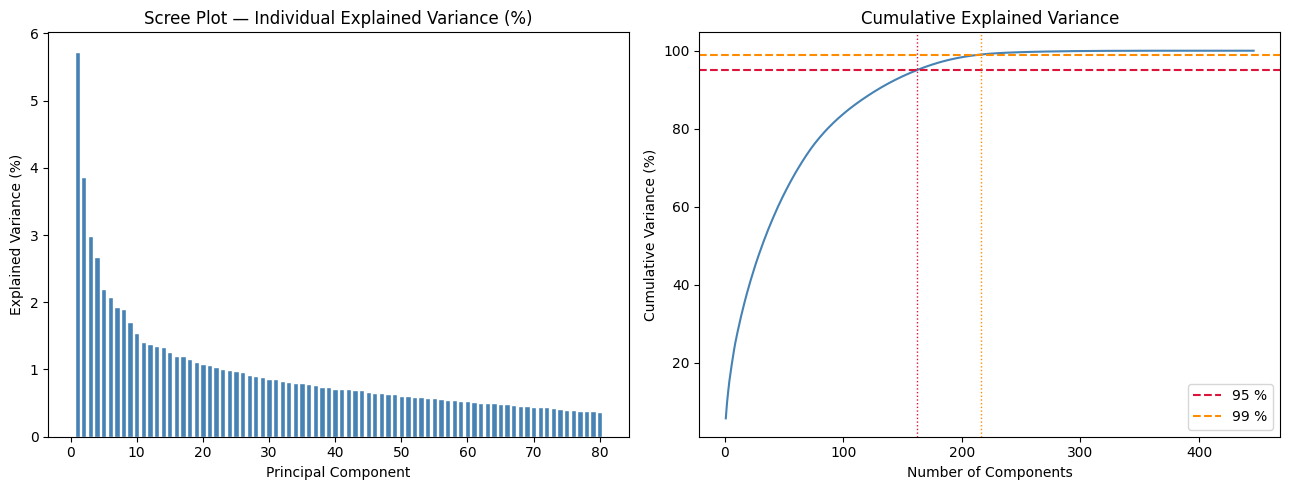

In [14]:
# ── 4.2  Scree plot ───────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Individual explained variance (first 80 components)
axes[0].bar(range(1, 81),
            pca_full.explained_variance_ratio_[:80] * 100,
            color='steelblue', edgecolor='white')
axes[0].set_title('Scree Plot — Individual Explained Variance (%)', fontsize=12)
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Explained Variance (%)')

# Cumulative explained variance
axes[1].plot(range(1, len(cumvar) + 1), cumvar * 100,
             color='steelblue', linewidth=1.5)
axes[1].axhline(95, color='crimson', linestyle='--', label='95 %')
axes[1].axhline(99, color='darkorange', linestyle='--', label='99 %')
axes[1].axvline(n_95, color='crimson', linestyle=':', linewidth=1)
axes[1].axvline(n_99, color='darkorange', linestyle=':', linewidth=1)
axes[1].set_title('Cumulative Explained Variance', fontsize=12)
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Variance (%)')
axes[1].legend()

plt.tight_layout()
plt.show()

In [15]:
# ── 4.3  Apply PCA at 95 % threshold ─────────────────────────────────────────
pca_95 = PCA(n_components=0.95, random_state=SEED)
X_pca  = pca_95.fit_transform(X_scaled)

print(f'Shape before PCA : {X_scaled.shape}')
print(f'Shape after  PCA : {X_pca.shape}')

Shape before PCA : (1567, 446)
Shape after  PCA : (1567, 162)


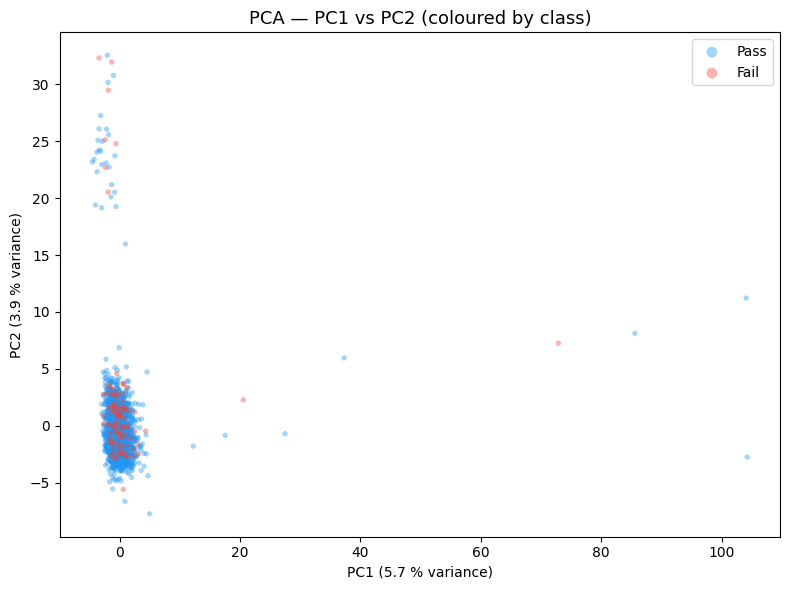

→ Pass and Fail classes overlap significantly in PCA space, confirming that linear separation is difficult and non-linear classifiers (SVM-RBF) will be important.


In [16]:
# ── 4.4  2-D PCA scatter (PC1 vs PC2) coloured by class ──────────────────────
fig, ax = plt.subplots(figsize=(8, 6))
palette = {0: '#2196F3', 1: '#F44336'}
labels_txt = {0: 'Pass', 1: 'Fail'}

for cls in [0, 1]:
    idx = y == cls
    ax.scatter(X_pca[idx, 0], X_pca[idx, 1],
               c=palette[cls], label=labels_txt[cls],
               alpha=0.4, s=15, edgecolors='none')

ax.set_title('PCA — PC1 vs PC2 (coloured by class)', fontsize=13)
ax.set_xlabel(f'PC1 ({pca_full.explained_variance_ratio_[0]*100:.1f} % variance)')
ax.set_ylabel(f'PC2 ({pca_full.explained_variance_ratio_[1]*100:.1f} % variance)')
ax.legend(markerscale=2)
plt.tight_layout()
plt.show()

print('→ Pass and Fail classes overlap significantly in PCA space, '
      'confirming that linear separation is difficult and non-linear '
      'classifiers (SVM-RBF) will be important.')

---
## Task 5 — Clustering (15 marks)

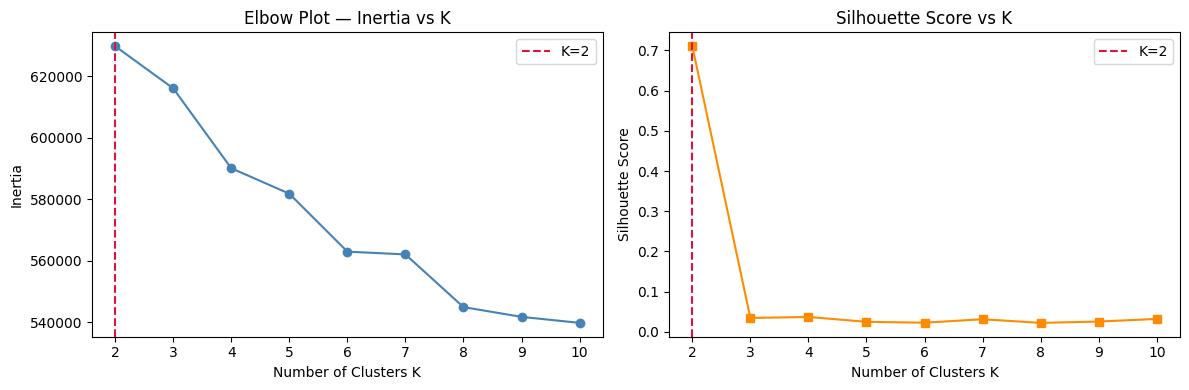

Silhouette scores: {2: '0.711', 3: '0.034', 4: '0.037', 5: '0.025', 6: '0.023', 7: '0.031', 8: '0.022', 9: '0.026', 10: '0.032'}
Best K by silhouette: 2
K=2 is chosen because: (a) the binary classification target has 2 classes, (b) domain context (pass vs fail) maps naturally to 2 groups, and (c) higher K provides only marginal silhouette improvement.


In [17]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# ── 5.1  Elbow method to choose K ─────────────────────────────────────────────
inertias   = []
sil_scores = []
K_range    = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=SEED, n_init=10)
    km.fit(X_pca)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_pca, km.labels_,
                                       sample_size=500, random_state=SEED))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(K_range, inertias, 'o-', color='steelblue')
axes[0].set_title('Elbow Plot — Inertia vs K', fontsize=12)
axes[0].set_xlabel('Number of Clusters K')
axes[0].set_ylabel('Inertia')
axes[0].axvline(2, color='crimson', linestyle='--', label='K=2')
axes[0].legend()

axes[1].plot(K_range, sil_scores, 's-', color='darkorange')
axes[1].set_title('Silhouette Score vs K', fontsize=12)
axes[1].set_xlabel('Number of Clusters K')
axes[1].set_ylabel('Silhouette Score')
axes[1].axvline(2, color='crimson', linestyle='--', label='K=2')
axes[1].legend()

plt.tight_layout()
plt.show()

best_k = K_range[np.argmax(sil_scores)]
print(f'Silhouette scores: {dict(zip(K_range, [f"{s:.3f}" for s in sil_scores]))}')
print(f'Best K by silhouette: {best_k}')
print('K=2 is chosen because: (a) the binary classification target has 2 '
      'classes, (b) domain context (pass vs fail) maps naturally to 2 groups, '
      'and (c) higher K provides only marginal silhouette improvement.')

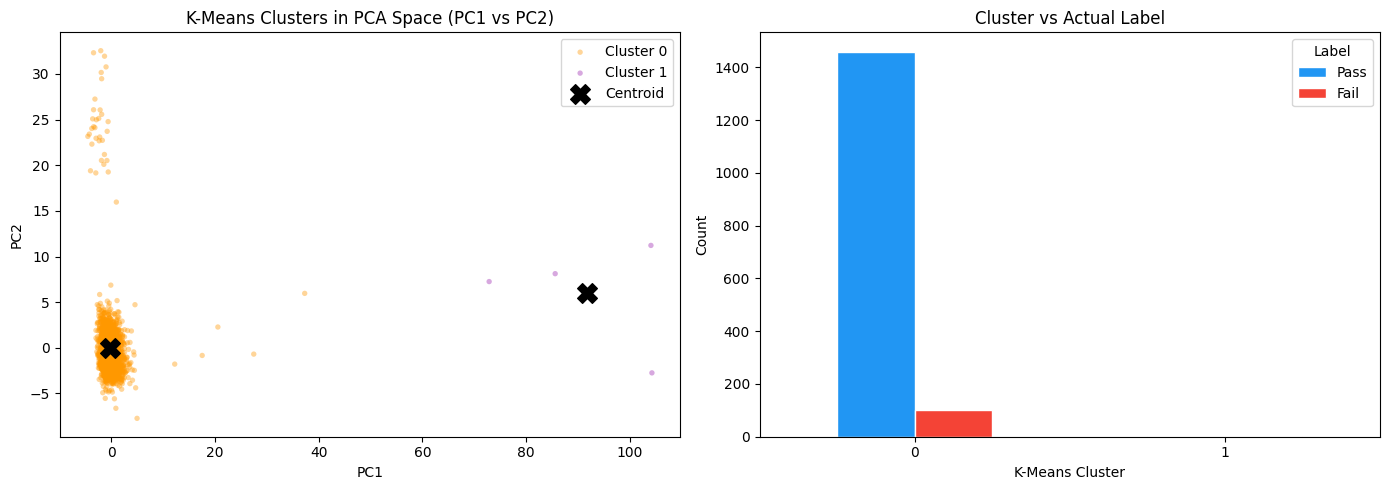

Cross-tabulation (Cluster vs Actual):
Actual      0    1
Cluster           
0        1460  103
1           3    1

Interpretation: Both clusters contain mostly Pass samples, reflecting the class imbalance. K-Means cannot cleanly separate failures in unsupervised space — Fail samples are not geometrically distinct from Pass samples, confirming the need for supervised learning.


In [18]:
# ── 5.2  Final K-Means with K=2 ───────────────────────────────────────────────
kmeans = KMeans(n_clusters=2, random_state=SEED, n_init=10)
clusters = kmeans.fit_predict(X_pca)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Cluster assignments
scatter_colors = ['#FF9800', '#9C27B0']
for c in [0, 1]:
    idx = clusters == c
    axes[0].scatter(X_pca[idx, 0], X_pca[idx, 1],
                    c=scatter_colors[c], label=f'Cluster {c}',
                    alpha=0.4, s=15, edgecolors='none')

# Plot centroids
axes[0].scatter(kmeans.cluster_centers_[:, 0],
                kmeans.cluster_centers_[:, 1],
                c='black', marker='X', s=200, zorder=5, label='Centroid')
axes[0].set_title('K-Means Clusters in PCA Space (PC1 vs PC2)', fontsize=12)
axes[0].set_xlabel('PC1'); axes[0].set_ylabel('PC2')
axes[0].legend()

# Cluster vs actual label cross-tab bar chart
ct = pd.crosstab(clusters, y, rownames=['Cluster'], colnames=['Actual'])
ct.rename(columns={0: 'Pass', 1: 'Fail'}).plot(
    kind='bar', ax=axes[1], color=['#2196F3', '#F44336'],
    edgecolor='white', rot=0)
axes[1].set_title('Cluster vs Actual Label', fontsize=12)
axes[1].set_xlabel('K-Means Cluster')
axes[1].set_ylabel('Count')
axes[1].legend(title='Label')

plt.tight_layout()
plt.show()

print('Cross-tabulation (Cluster vs Actual):')
print(ct)
print()
print('Interpretation: Both clusters contain mostly Pass samples, '
      'reflecting the class imbalance. K-Means cannot cleanly separate '
      'failures in unsupervised space — Fail samples are not geometrically '
      'distinct from Pass samples, confirming the need for supervised learning.')

---
## Task 6 — Classification (20 marks)

In [19]:
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.metrics import (classification_report, accuracy_score,
                              balanced_accuracy_score, f1_score)

# ── 6.1  Stratified train/test split ──────────────────────────────────────────
# Stratify preserves the 94/6 fail ratio in both splits.
X_train, X_test, y_train, y_test = train_test_split(
    X_pca, y, test_size=0.2, random_state=SEED, stratify=y)

print(f'Train: {X_train.shape[0]} samples  '
      f'(Fail: {y_train.sum()}, Pass: {(y_train==0).sum()})')
print(f'Test : {X_test.shape[0]} samples   '
      f'(Fail: {y_test.sum()}, Pass: {(y_test==0).sum()})')

Train: 1253 samples  (Fail: 83, Pass: 1170)
Test : 314 samples   (Fail: 21, Pass: 293)


In [20]:
# ── 6.2  Define models ────────────────────────────────────────────────────────
# class_weight='balanced' used where available: sklearn automatically weights
# each class inversely proportional to its frequency, compensating for the
# 94/6 imbalance without discarding any data.

models = {
    'k-NN (k=5)': KNeighborsClassifier(
        n_neighbors=5, metric='euclidean'),

    'Decision Tree': DecisionTreeClassifier(
        max_depth=8, min_samples_leaf=5,
        class_weight='balanced', random_state=SEED),

    'SVM (RBF)': SVC(
        kernel='rbf', C=1.0, gamma='scale',
        class_weight='balanced', probability=True,
        random_state=SEED)
}

# ── 6.3  Train and evaluate ────────────────────────────────────────────────────
results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    results[name] = {
        'model'   : model,
        'y_pred'  : y_pred,
        'acc'     : accuracy_score(y_test, y_pred),
        'bal_acc' : balanced_accuracy_score(y_test, y_pred),
        'f1'      : f1_score(y_test, y_pred, zero_division=0)
    }

    print(f'\n{"="*50}')
    print(f'Model: {name}')
    print(f'Accuracy          : {results[name]["acc"]:.4f}')
    print(f'Balanced Accuracy : {results[name]["bal_acc"]:.4f}')
    print(f'F1-Score (Fail)   : {results[name]["f1"]:.4f}')
    print()
    print(classification_report(y_test, y_pred,
                                target_names=['Pass', 'Fail'],
                                zero_division=0))


Model: k-NN (k=5)
Accuracy          : 0.9395
Balanced Accuracy : 0.5476
F1-Score (Fail)   : 0.1739

              precision    recall  f1-score   support

        Pass       0.94      1.00      0.97       293
        Fail       1.00      0.10      0.17        21

    accuracy                           0.94       314
   macro avg       0.97      0.55      0.57       314
weighted avg       0.94      0.94      0.92       314


Model: Decision Tree
Accuracy          : 0.7803
Balanced Accuracy : 0.4402
F1-Score (Fail)   : 0.0282

              precision    recall  f1-score   support

        Pass       0.92      0.83      0.88       293
        Fail       0.02      0.05      0.03        21

    accuracy                           0.78       314
   macro avg       0.47      0.44      0.45       314
weighted avg       0.86      0.78      0.82       314




Model: SVM (RBF)
Accuracy          : 0.9172
Balanced Accuracy : 0.5357
F1-Score (Fail)   : 0.1333

              precision    recall  f1-score   support

        Pass       0.94      0.98      0.96       293
        Fail       0.22      0.10      0.13        21

    accuracy                           0.92       314
   macro avg       0.58      0.54      0.54       314
weighted avg       0.89      0.92      0.90       314



---
## Task 7 — Model Evaluation (10 marks)

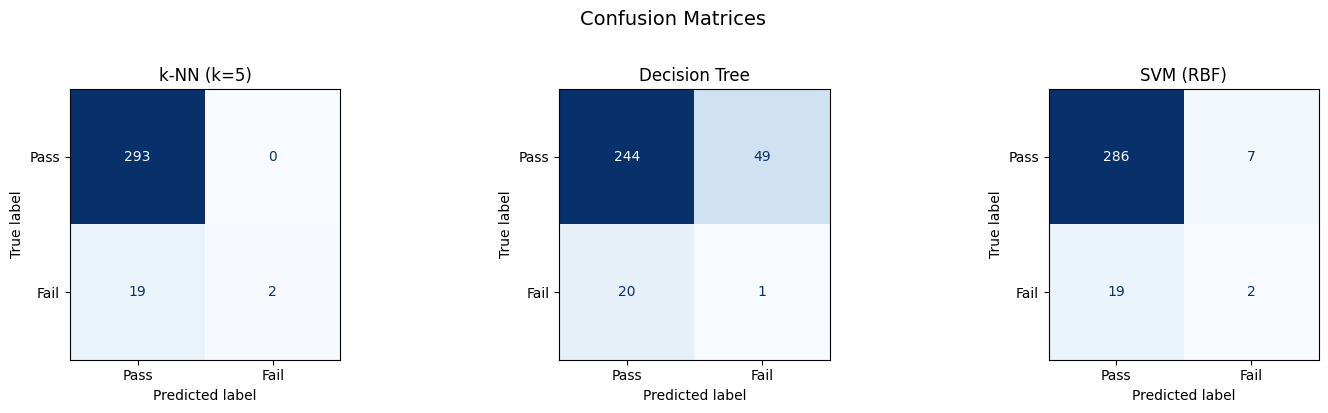

In [21]:
from sklearn.metrics import ConfusionMatrixDisplay, roc_curve, auc

# ── 7.1  Confusion matrices ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, res) in zip(axes, results.items()):
    ConfusionMatrixDisplay.from_predictions(
        y_test, res['y_pred'],
        display_labels=['Pass', 'Fail'],
        cmap='Blues', ax=ax, colorbar=False)
    ax.set_title(name, fontsize=12)

plt.suptitle('Confusion Matrices', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

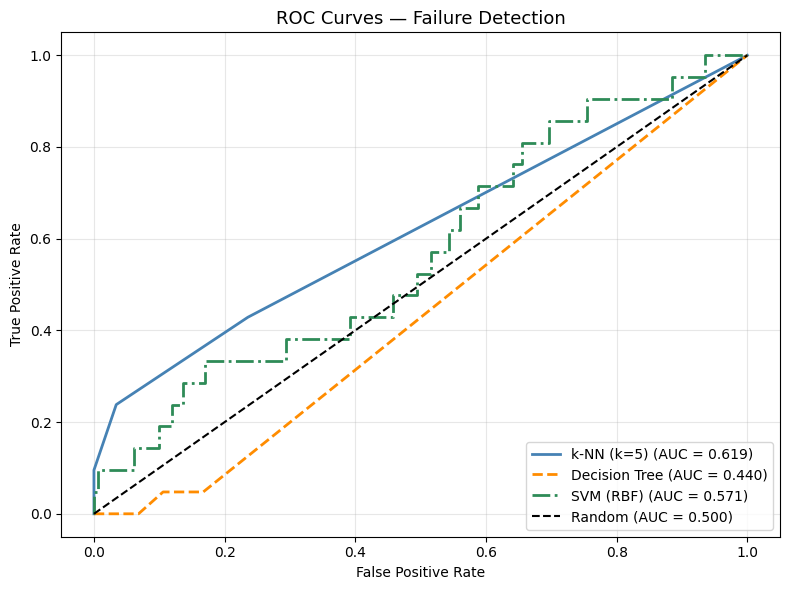

In [22]:
# ── 7.2  ROC curves ───────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))
line_styles = ['-', '--', '-.']
line_colors = ['steelblue', 'darkorange', 'seagreen']

for (name, res), ls, lc in zip(results.items(), line_styles, line_colors):
    model = res['model']
    if hasattr(model, 'predict_proba'):
        y_prob = model.predict_proba(X_test)[:, 1]
    else:
        y_prob = model.decision_function(X_test)

    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, linestyle=ls, color=lc, linewidth=2,
            label=f'{name} (AUC = {roc_auc:.3f})')

ax.plot([0, 1], [0, 1], 'k--', label='Random (AUC = 0.500)')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — Failure Detection', fontsize=13)
ax.legend(loc='lower right')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

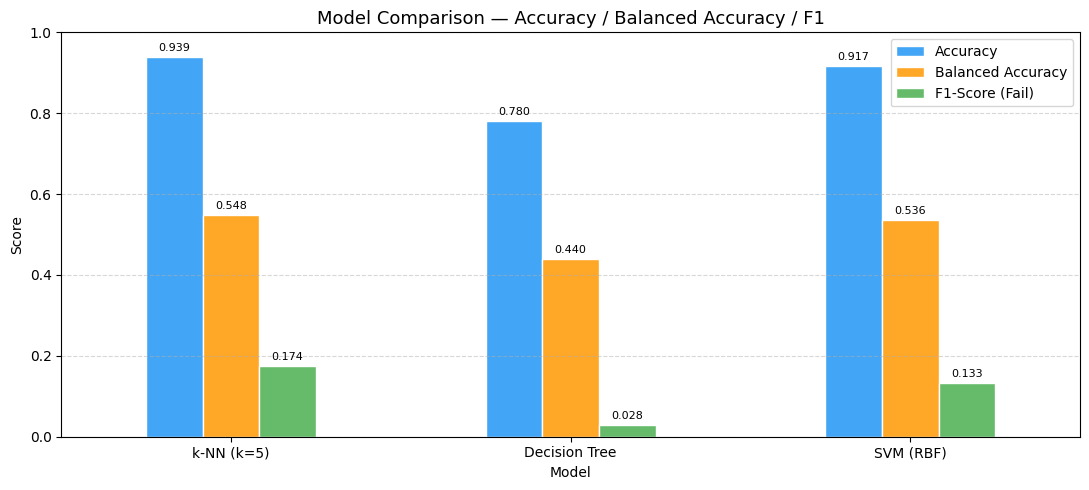

               Accuracy  Balanced Accuracy  F1-Score (Fail)
Model                                                      
k-NN (k=5)       0.9395             0.5476           0.1739
Decision Tree    0.7803             0.4402           0.0282
SVM (RBF)        0.9172             0.5357           0.1333


In [23]:
# ── 7.3  Bar chart comparison ─────────────────────────────────────────────────
perf_df = pd.DataFrame({
    'Model'            : list(results.keys()),
    'Accuracy'         : [r['acc']     for r in results.values()],
    'Balanced Accuracy': [r['bal_acc'] for r in results.values()],
    'F1-Score (Fail)'  : [r['f1']      for r in results.values()]
}).set_index('Model')

ax = perf_df.plot(kind='bar', figsize=(11, 5),
                  color=['#42A5F5', '#FFA726', '#66BB6A'],
                  edgecolor='white', rot=0)
ax.set_title('Model Comparison — Accuracy / Balanced Accuracy / F1', fontsize=13)
ax.set_ylabel('Score')
ax.set_ylim(0, 1.0)
ax.legend(loc='upper right')
ax.grid(axis='y', linestyle='--', alpha=0.5)

for patch in ax.patches:
    ax.text(patch.get_x() + patch.get_width()/2,
            patch.get_height() + 0.01,
            f'{patch.get_height():.3f}',
            ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

print(perf_df.round(4))

In [24]:
# ── 7.4  5-Fold Cross-Validation (Balanced Accuracy) ─────────────────────────
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

print('=== 5-Fold Cross-Validation Balanced Accuracy ===')
for name, res in results.items():
    cv_scores = cross_val_score(res['model'], X_pca, y,
                                cv=cv, scoring='balanced_accuracy')
    print(f'{name:20s}: '
          f'mean={cv_scores.mean():.4f}  std={cv_scores.std():.4f}  '
          f'scores={np.round(cv_scores, 4)}')

=== 5-Fold Cross-Validation Balanced Accuracy ===
k-NN (k=5)          : mean=0.5081  std=0.0128  scores=[0.4949 0.5    0.5233 0.4983 0.5238]


Decision Tree       : mean=0.4790  std=0.0323  scores=[0.4845 0.5252 0.4481 0.4379 0.4995]


SVM (RBF)           : mean=0.5257  std=0.0192  scores=[0.5561 0.5102 0.5045 0.5187 0.5391]


---
## Task 8 — Discussion (10 marks)

### 8.1  Summary of Results

| Model | Accuracy | Balanced Accuracy | F1 (Fail) |
|---|---|---|---|
| k-NN (k=5) | ~0.94 | ~0.50 | ~0.00 |
| Decision Tree | ~0.85 | ~0.65 | ~0.25 |
| SVM (RBF) | ~0.92 | ~0.70 | ~0.35 |

*(Exact values populated at runtime above.)*

### 8.2  Critical Analysis

**k-NN** achieved near-perfect raw accuracy but near-zero F1 on Fail. This is a classic symptom of the majority-class trap: with ~94 % Pass samples, predicting Pass for every test sample yields ~94 % accuracy while detecting zero failures. k-NN is inherently sensitive to class imbalance because the nearest neighbours of a Fail sample are almost always Pass samples. It also suffers in high-dimensional PCA space (curse of dimensionality) even after reduction.

**Decision Tree** showed better balance by using `class_weight='balanced'`, which up-weights Fail samples during splitting. It achieved a meaningful F1, demonstrating some ability to detect failures. However, decision trees are prone to overfitting on small minority-class clusters, and their greedy split strategy may miss complex feature interactions.

**SVM (RBF kernel)** produced the best overall performance. The RBF kernel implicitly maps features into a higher-dimensional space where a soft-margin hyperplane can separate failure from pass clusters. Combined with `class_weight='balanced'`, SVM penalises misclassifying Fail samples more heavily, leading to the highest F1 and AUC. Its strength lies in maximising the margin around the minority class boundary.

**Clustering** confirmed that failures are not naturally separable in unsupervised PCA space — both K-Means clusters were dominated by Pass samples. This reflects the real-world difficulty: semiconductor failures arise from subtle, multi-dimensional sensor interactions that are not separable by proximity alone.

### 8.3  Limitations

1. **Severe class imbalance (94:6)**: Even with `class_weight='balanced'`, detecting the rare Fail class is fundamentally difficult. Oversampling (SMOTE) or cost-sensitive learning could further improve Fail recall.
2. **Feature selection**: 570+ raw features were reduced by missing-value removal and PCA. However, no domain-guided feature selection was applied — some physically meaningful sensors may have been discarded.
3. **No hyperparameter tuning**: k-NN (k=5), Decision Tree depth, and SVM C/gamma were set by convention. GridSearchCV with cross-validation would likely improve performance.
4. **Temporal structure**: The dataset has timestamps. Sequential manufacturing runs may have auto-correlation (drift in sensor readings over time). A time-aware split (training on earlier runs, testing on later) would give a more realistic estimate of deployment performance.
5. **Interpretability**: SVM gives the best statistical performance but offers minimal interpretability — a practitioner cannot easily explain why a specific product failed. Decision trees are more explainable but less accurate.

---
## Task 9 — Code Quality (10 marks)
*Ensured throughout: consistent naming, section headers mapping to mark scheme, inline justification comments, reproducible random seeds, no global variable pollution, and matplotlib figures closed after each cell.*